Parameters:

learning rate 0.01, batch size 64
- hidden nodes 20: age test: 63.08% | sex test: 73.08%
- hidden nodes 50: age test 57.69% | sex test: 67.69%
- hidden nodes 100: age test 51.54% | sex test: 70.77%

Parameters:

learning rate 0.01, batch size 32

- hidden nodes=20: age test=0.6154 | sex test=0.7308
- hidden nodes=50: age test=0.6077 | sex test=0.7615
- hidden nodes=100: age test=0.5462 | sex test=0.6923

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
!{sys.executable} -m pip install pyexiftool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 5.2 MB/s eta 0:00:00


In [ ]:
!sudo apt-get update
!sudo apt-get install -y exiftool

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:13 https://ppa.launchpadcontent.net/deadsnakes/p

Test Code to see what metadata looks like

- documentation: https://pypi.org/project/PyExifTool/

In [ ]:

import exiftool

files = ['IMG_0214.JPG']

with exiftool.ExifToolHelper() as et:
    metadata = et.get_metadata(files)
    for d in metadata:
        print(f"{d.get('SourceFile', ''):20.20}", end=" ")

        # Try multiple possible description fields
        description = (
            d.get("EXIF:ImageDescription") or
            d.get("IPTC:Caption-Abstract") or
            d.get("XMP:Subject") or
            "No description found"
        )

        print(description)

IMG_0214.JPG         [2006, 'juv', 'LM-06-009', 'M', 'Wing']


# Rename each file as filename_year then extract all metadata into a csv file.

Asked gemini for help

In [ ]:
import csv
from pathlib import Path
import exiftool

# CHANGE THIS to your actual folder
ROOT = Path("/content/drive/MyDrive/Wings") # CHANGE PATH TO YOUR PATH

YEARS = [str(year) for year in range(2006, 2015)]
OUTPUT_CSV = "wings_metadata.csv"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".gif", ".heic", ".webp"}


def is_image_file(path: Path) -> bool:
    return path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS


def make_unique_path(folder: Path, stem: str, suffix: str) -> Path:
    candidate = folder / f"{stem}{suffix}"
    counter = 1
    while candidate.exists():
        candidate = folder / f"{stem}_{counter}{suffix}"
        counter += 1
    return candidate


def flatten_value(value):
    if isinstance(value, list):
        return "; ".join(str(v) for v in value)
    if isinstance(value, dict):
        return str(value)
    return value


def debug_folders(): # make sure the root exists
    print("ROOT exists:", ROOT.exists())
    print("ROOT path:", ROOT)

    if ROOT.exists():
        print("\nContents of ROOT:")
        for p in sorted(ROOT.iterdir()):
            print(" -", p.name, "(dir)" if p.is_dir() else "(file)")
    else:
        print("\nROOT does not exist. Check the exact path.")


def rename_images(): # renames images ime_name_year
    renamed_files = []

    for year in YEARS:
        year_folder = ROOT / year

        if not year_folder.exists():
            print(f"Skipping missing folder: {year_folder}")
            continue

        print(f"Processing folder: {year_folder}")

        for path in year_folder.iterdir():
            if not is_image_file(path):
                continue

            old_stem = path.stem
            suffix = path.suffix

            if old_stem.endswith(f"_{year}"):
                new_path = path
            else:
                new_stem = f"{old_stem}_{year}"
                new_path = make_unique_path(year_folder, new_stem, suffix)

                if path != new_path:
                    print(f"Renaming: {path.name} -> {new_path.name}")
                    path.rename(new_path)

            renamed_files.append(new_path)

    return renamed_files


def extract_metadata_to_csv(files, output_csv): #extracts all metadata using exiftool
    if not files:
        print("No image files found.")
        return

    with exiftool.ExifToolHelper() as et:
        metadata_list = et.get_metadata([str(f) for f in files])

    all_keys = set()
    rows = []

    for d in metadata_list:
        source_file = d.get("SourceFile", "")
        source_path = Path(source_file)

        row = {
            "file_path": str(source_path),
            "file_name": source_path.name,
            "year_folder": source_path.parent.name,
        }

        for key, value in d.items():
            row[key] = flatten_value(value)
            all_keys.add(key)

        rows.append(row)

    preferred = ["file_path", "file_name", "year_folder", "SourceFile"]
    remaining = sorted(k for k in all_keys if k not in preferred)
    fieldnames = preferred + remaining

    with open(output_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved metadata for {len(rows)} images to {output_csv}")


if __name__ == "__main__":
    debug_folders()
    renamed_files = rename_images()
    extract_metadata_to_csv(renamed_files, OUTPUT_CSV)

ROOT exists: True
ROOT path: /content/drive/MyDrive/Wings

Contents of ROOT:
 - 2006 (dir)
 - 2007 (dir)
 - 2008 (dir)
 - 2009 (dir)
 - 2010 (dir)
 - 2011 (dir)
 - 2012 (dir)
 - 2013 (dir)
 - 2014 (dir)
Processing folder: /content/drive/MyDrive/Wings/2006
Processing folder: /content/drive/MyDrive/Wings/2007
Processing folder: /content/drive/MyDrive/Wings/2008
Processing folder: /content/drive/MyDrive/Wings/2009
Processing folder: /content/drive/MyDrive/Wings/2010
Processing folder: /content/drive/MyDrive/Wings/2011
Processing folder: /content/drive/MyDrive/Wings/2012
Processing folder: /content/drive/MyDrive/Wings/2013
Processing folder: /content/drive/MyDrive/Wings/2014
Saved metadata for 650 images to wings_metadata.csv


Test code to extract true labels

In [ ]:
import pandas as pd

wings_df = pd.read_csv("wings_metadata.csv")
# wings_df.head()



# age_sex_df = wings_df[['Year', 'Age', 'Code', 'Sex', 'Wing']] = wings_df['XMP:Subject'].str.split(';', expand=True)

# age_sex_df = age_sex_df.set_axis(['Year', 'Age', 'Code', 'Sex', 'Wing'], axis=1)

# # age_sex_df = age_sex_df.drop(columns=['Year', 'Code', 'Wing'], axis=1)

# # age_sex_df['filename']= wings_df['file_name']

# age_sex_df

FileNotFoundError: [Errno 2] No such file or directory: 'wings_metadata.csv'

The data was split from the column XMP:Subject as this included the info about the age and sex. Tried splitting the data using a delimiter but due to uneven data collection the values were mapped wrong. Decided to switch to regex for column mapping.

In [ ]:
import pandas as pd
import re

def parse_subject(text):
    # Default structure
    result = {
        "year": None,
        "age": None,
        "id": None,
        "sex": None,
        "type": None
    }

    if pd.isna(text):
        return result

    parts = [p.strip() for p in text.split(";")]

    for p in parts:
        if re.fullmatch(r"\d{4}", p):
            result["year"] = int(p)

        elif p.lower() in {"juv", "ad"}:
            result["age"] = p.lower()

        elif re.fullmatch(r"[A-Z]{2}-\d{2}-\d{3}", p):
            result["id"] = p

        elif p in {"M", "F"}:
            result["sex"] = p

        else:
            # fallback (like "Wing")
            result["type"] = p

    return result


# Apply to dataframe column
parsed = wings_df["XMP:Subject"].apply(parse_subject)

# Convert to dataframe
parsed_df = pd.DataFrame(parsed.tolist())

parsed_df = parsed_df.drop(columns=['year', 'id', 'type'], axis=1)

parsed_df['filename']= wings_df['file_name']

parsed_df.to_csv('training set image labels.csv') # True label

parsed_df


NameError: name 'wings_df' is not defined

# Neural Network

got the base code from CS 545 Machine Learning Class. We worked with the same code but with MNIST dataset

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# =========================================================
# Config
# =========================================================
CSV_PATH = "training set image labels.csv"
IMAGE_DIR = "/content/drive/MyDrive/Wings"   # images are in /Wings/<year>/<filename>
IMAGE_SIZE = (32, 32)                        # good starting size for MLP
TEST_SIZE = 0.2
SEED = 42
GRAYSCALE = False                            # set True to reduce input size


# =========================================================
# Path helper
# =========================================================
def get_image_path(base_dir, filename):
    """
    Build full path from filename like IMG_0214_2006.JPG
    -> /content/drive/MyDrive/Wings/2006/IMG_0214_2006.JPG
    """
    year = str(filename).split("_")[-1].split(".")[0]
    return os.path.join(base_dir, year, filename)


# =========================================================
# Data loading for multi-output MLP
# =========================================================
def load_wings_mlp_multi(
    csv_path=CSV_PATH,
    image_dir=IMAGE_DIR,
    image_size=IMAGE_SIZE,
    test_size=TEST_SIZE,
    seed=SEED,
    grayscale=GRAYSCALE
):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    required_cols = ["filename", "age", "sex"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"CSV is missing required columns: {missing_cols}")

    df = df.dropna(subset=required_cols).copy()

    # keep only files that exist
    df["exists"] = df["filename"].apply(lambda f: os.path.exists(get_image_path(image_dir, f)))
    df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

    if len(df) == 0:
        raise ValueError("No matching image files were found. Check CSV_PATH and IMAGE_DIR.")

    # encode labels separately
    age_classes = sorted(df["age"].astype(str).unique())
    sex_classes = sorted(df["sex"].astype(str).unique())

    age_to_idx = {label: i for i, label in enumerate(age_classes)}
    sex_to_idx = {label: i for i, label in enumerate(sex_classes)}

    idx_to_age = {i: label for label, i in age_to_idx.items()}
    idx_to_sex = {i: label for label, i in sex_to_idx.items()}

    X = []
    y_age = []
    y_sex = []

    for _, row in df.iterrows():
        path = get_image_path(image_dir, row["filename"])

        if grayscale:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        else:
            img = cv2.imread(path, cv2.IMREAD_COLOR)

        if img is None:
            continue

        img = cv2.resize(img, image_size)
        img = img.astype(np.float32) / 255.0
        img = img.flatten()

        X.append(img)
        y_age.append(age_to_idx[str(row["age"])])
        y_sex.append(sex_to_idx[str(row["sex"])])

    X = np.array(X, dtype=np.float32)
    y_age = np.array(y_age, dtype=np.int64)
    y_sex = np.array(y_sex, dtype=np.int64)

    # stratify on combined labels so both tasks stay balanced
    stratify_labels = np.array([f"{a}_{s}" for a, s in zip(y_age, y_sex)])

    X_train, X_test, y_age_train, y_age_test, y_sex_train, y_sex_test = train_test_split(
        X, y_age, y_sex,
        test_size=test_size,
        random_state=seed,
        stratify=stratify_labels
    )

    label_maps = {
        "age_to_idx": age_to_idx,
        "sex_to_idx": sex_to_idx,
        "idx_to_age": idx_to_age,
        "idx_to_sex": idx_to_sex
    }

    return X_train, y_age_train, y_sex_train, X_test, y_age_test, y_sex_test, label_maps


# =========================================================
# Utility functions
# =========================================================
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot_encode(y, n_classes):
    out = np.zeros((len(y), n_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out

def add_bias(X):
    return np.hstack([X, np.ones((X.shape[0], 1), dtype=X.dtype)])

def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)


# =========================================================
# Forward / predict for multi-output MLP
# =========================================================
def mlp_forward_multi(X, weights_hidden, weights_age, weights_sex):
    Xb = add_bias(X)

    hidden_net = Xb @ weights_hidden
    hidden_out = sigmoid(hidden_net)
    hidden_b = add_bias(hidden_out)

    age_net = hidden_b @ weights_age
    sex_net = hidden_b @ weights_sex

    age_out = softmax(age_net)
    sex_out = softmax(sex_net)

    return Xb, hidden_out, hidden_b, age_out, sex_out


def mlp_predict_multi(X, weights_hidden, weights_age, weights_sex):
    _, _, _, age_out, sex_out = mlp_forward_multi(X, weights_hidden, weights_age, weights_sex)
    age_pred = np.argmax(age_out, axis=1)
    sex_pred = np.argmax(sex_out, axis=1)
    return age_pred, sex_pred, age_out, sex_out


# =========================================================
# Multi-output training
# =========================================================
def mlp_train_multi(
    X_train, y_age_train, y_sex_train,
    X_test, y_age_test, y_sex_test,
    n_hidden=100,
    eta=0.01,
    momentum=0.9,
    epochs=50,
    batch_size=64, # New parameter
    seed=42
):
    rng = np.random.default_rng(seed)

    n_samples, n_input = X_train.shape
    n_age_classes = len(np.unique(y_age_train))
    n_sex_classes = len(np.unique(y_sex_train))

    y_age_train_oh = one_hot_encode(y_age_train, n_age_classes)
    y_sex_train_oh = one_hot_encode(y_sex_train, n_sex_classes)

    # weights
    weights_hidden = rng.normal(0, 0.1, size=(n_input + 1, n_hidden)).astype(np.float32)
    weights_age = rng.normal(0, 0.1, size=(n_hidden + 1, n_age_classes)).astype(np.float32)
    weights_sex = rng.normal(0, 0.1, size=(n_hidden + 1, n_sex_classes)).astype(np.float32)

    # momentum buffers
    vel_hidden = np.zeros_like(weights_hidden)
    vel_age = np.zeros_like(weights_age)
    vel_sex = np.zeros_like(weights_sex)

    train_age_accs = []
    test_age_accs = []
    train_sex_accs = []
    test_sex_accs = []

    for epoch in range(epochs):
        # Shuffle data for each epoch
        permutation = rng.permutation(n_samples)
        X_train_shuffled = X_train[permutation]
        y_age_train_shuffled = y_age_train[permutation]
        y_sex_train_shuffled = y_sex_train[permutation]
        y_age_train_oh_shuffled = y_age_train_oh[permutation]
        y_sex_train_oh_shuffled = y_sex_train_oh[permutation]

        for i in range(0, n_samples, batch_size):
            X_batch = X_train_shuffled[i:i + batch_size]
            y_age_batch = y_age_train_shuffled[i:i + batch_size]
            y_sex_batch = y_sex_train_shuffled[i:i + batch_size]
            y_age_batch_oh = y_age_train_oh_shuffled[i:i + batch_size]
            y_sex_batch_oh = y_sex_train_oh_shuffled[i:i + batch_size]

            n_batch = len(X_batch) # Actual batch size for current batch

            # forward pass for the batch
            Xb_batch, hidden_out_batch, hidden_b_batch, age_out_batch, sex_out_batch = mlp_forward_multi(
                X_batch, weights_hidden, weights_age, weights_sex
            )

            # output errors for the batch
            error_age_batch = age_out_batch - y_age_batch_oh
            error_sex_batch = sex_out_batch - y_sex_batch_oh

            # grads for output heads for the batch
            grad_age = hidden_b_batch.T @ error_age_batch / n_batch
            grad_sex = hidden_b_batch.T @ error_sex_batch / n_batch

            # backprop to shared hidden layer for the batch
            hidden_error_from_age_batch = error_age_batch @ weights_age[:-1].T
            hidden_error_from_sex_batch = error_sex_batch @ weights_sex[:-1].T
            error_hidden_batch = (hidden_error_from_age_batch + hidden_error_from_sex_batch) * hidden_out_batch * (1 - hidden_out_batch)

            grad_hidden = Xb_batch.T @ error_hidden_batch / n_batch

            # update with momentum
            vel_age = momentum * vel_age - eta * grad_age
            vel_sex = momentum * vel_sex - eta * grad_sex
            vel_hidden = momentum * vel_hidden - eta * grad_hidden

            weights_age += vel_age
            weights_sex += vel_sex
            weights_hidden += vel_hidden

        # metrics (calculated on full training set after all batches)
        age_train_pred, sex_train_pred, _, _ = mlp_predict_multi(X_train, weights_hidden, weights_age, weights_sex)
        age_test_pred, sex_test_pred, _, _ = mlp_predict_multi(X_test, weights_hidden, weights_age, weights_sex)

        age_train_acc = accuracy_score(y_age_train, age_train_pred)
        age_test_acc = accuracy_score(y_age_test, age_test_pred)

        sex_train_acc = accuracy_score(y_sex_train, sex_train_pred)
        sex_test_acc = accuracy_score(y_sex_test, sex_test_pred)

        train_age_accs.append(age_train_acc)
        test_age_accs.append(age_test_acc)
        train_sex_accs.append(sex_train_acc)
        test_sex_accs.append(sex_test_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"age train={age_train_acc:.4f} test={age_test_acc:.4f} | "
            f"sex train={sex_train_acc:.4f} test={sex_test_acc:.4f}"
        )

    history = {
        "train_age_accs": train_age_accs,
        "test_age_accs": test_age_accs,
        "train_sex_accs": train_sex_accs,
        "test_sex_accs": test_sex_accs,
    }

    return weights_hidden, weights_age, weights_sex, history


# =========================================================
# Balanced subset helper
# =========================================================
def make_balanced_subset_multi(X, y_age, y_sex, fraction=0.5, seed=42):
    rng = np.random.default_rng(seed)

    combo_labels = np.array([f"{a}_{s}" for a, s in zip(y_age, y_sex)])
    unique_combos = np.unique(combo_labels)

    indices = []
    for combo in unique_combos:
        combo_idx = np.where(combo_labels == combo)[0]
        n_take = max(1, int(len(combo_idx) * fraction))
        chosen = rng.choice(combo_idx, size=n_take, replace=False)
        indices.extend(chosen.tolist())

    indices = np.array(indices)
    rng.shuffle(indices)

    return X[indices], y_age[indices], y_sex[indices]


# =========================================================
# Plotting
# =========================================================
def plot_results_multi(results, title="Multi-output MLP Performance"):
    plt.figure(figsize=(12, 6))

    for name, (_, _, _, history) in results.items():
        plt.plot(history["train_age_accs"], label=f"train age {name}")
        plt.plot(history["test_age_accs"], linestyle="--", label=f"test age {name}")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Age")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    for name, (_, _, _, history) in results.items():
        plt.plot(history["train_sex_accs"], label=f"train sex {name}")
        plt.plot(history["test_sex_accs"], linestyle="--", label=f"test sex {name}")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Sex")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_single(y_true, y_pred, idx_to_label, title="", filename=None):
    labels = sorted(idx_to_label.keys())
    display_labels = [idx_to_label[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax)
    plt.title(title)
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=150, bbox_inches="tight")

    plt.show()


Loaded data:
X_train: (518, 3072)
X_test : (130, 3072)
Age classes: {'ad': 0, 'juv': 1}
Sex classes: {'F': 0, 'M': 1}

Training model with n_hidden=20
Epoch 01/42 | age train=0.6023 test=0.6077 | sex train=0.5676 test=0.5538
Epoch 02/42 | age train=0.6023 test=0.6077 | sex train=0.5695 test=0.5308
Epoch 03/42 | age train=0.5849 test=0.5769 | sex train=0.5927 test=0.5385
Epoch 04/42 | age train=0.6023 test=0.6077 | sex train=0.5927 test=0.5769
Epoch 05/42 | age train=0.5849 test=0.5538 | sex train=0.6081 test=0.5615
Epoch 06/42 | age train=0.6023 test=0.6077 | sex train=0.6467 test=0.6231
Epoch 07/42 | age train=0.6023 test=0.6077 | sex train=0.6544 test=0.6231
Epoch 08/42 | age train=0.6023 test=0.6077 | sex train=0.6255 test=0.5615
Epoch 09/42 | age train=0.6023 test=0.6077 | sex train=0.6602 test=0.6538
Epoch 10/42 | age train=0.6023 test=0.6077 | sex train=0.6486 test=0.6231
Epoch 11/42 | age train=0.6062 test=0.5923 | sex train=0.6274 test=0.5769
Epoch 12/42 | age train=0.6042 test

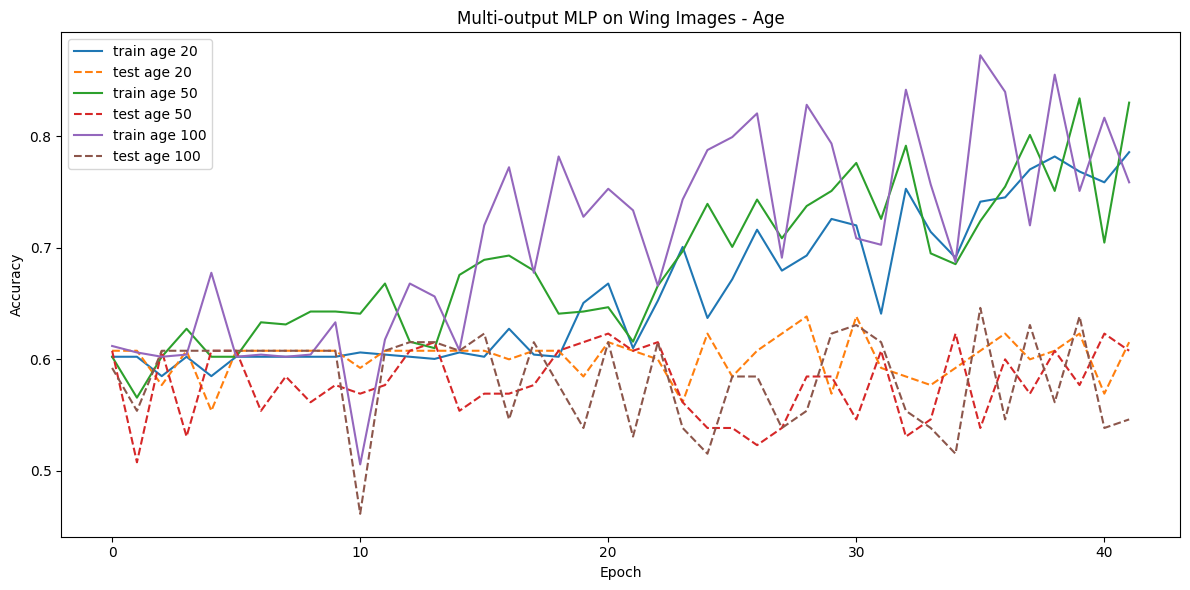

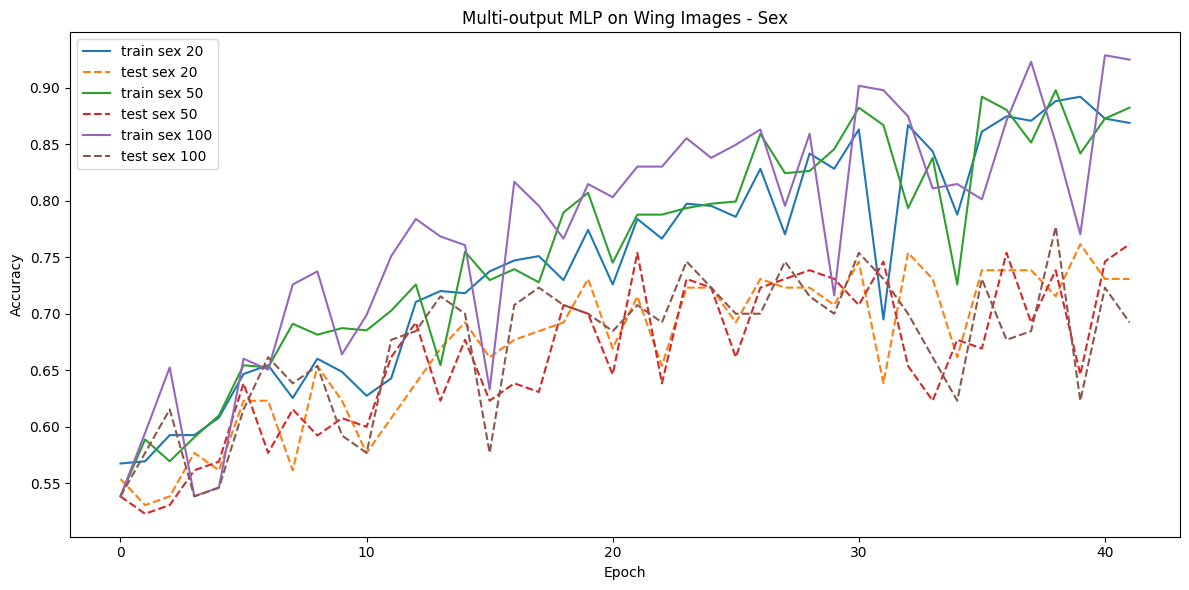


Final accuracies:
hidden nodes=20: age train=0.7857, age test=0.6154 | sex train=0.8687, sex test=0.7308
hidden nodes=50: age train=0.8301, age test=0.6077 | sex train=0.8822, sex test=0.7615
hidden nodes=100: age train=0.7587, age test=0.5462 | sex train=0.9247, sex test=0.6923

Results for hidden nodes=20

Age Confidence Scores (first 5 samples):
 [[0.163 0.837]
 [0.261 0.739]
 [0.727 0.273]
 [0.193 0.807]
 [0.237 0.763]]

Sex Confidence Scores (first 5 samples):
 [[0.817 0.183]
 [0.876 0.124]
 [0.196 0.804]
 [0.967 0.033]
 [0.183 0.817]]


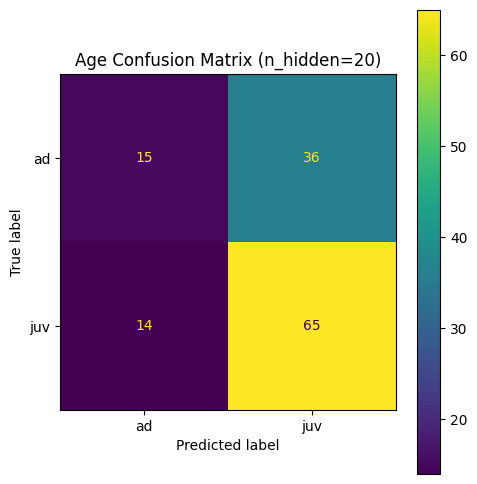

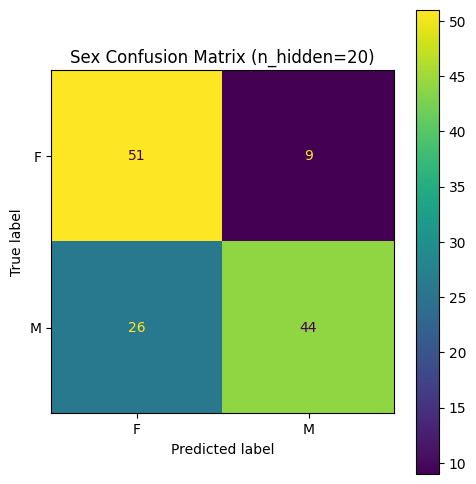


Results for hidden nodes=50

Age Confidence Scores (first 5 samples):
 [[0.212 0.788]
 [0.319 0.681]
 [0.677 0.323]
 [0.227 0.773]
 [0.297 0.703]]

Sex Confidence Scores (first 5 samples):
 [[0.926 0.074]
 [0.821 0.179]
 [0.185 0.815]
 [0.984 0.016]
 [0.206 0.794]]


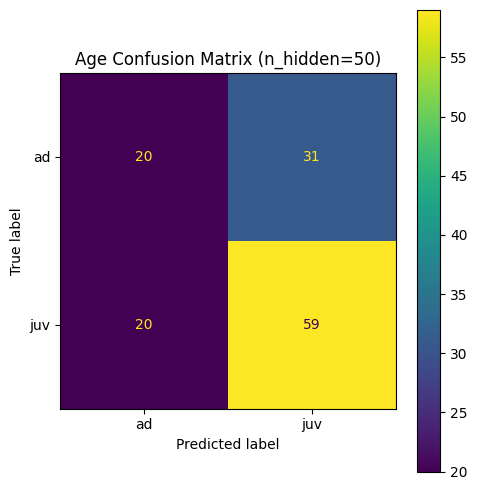

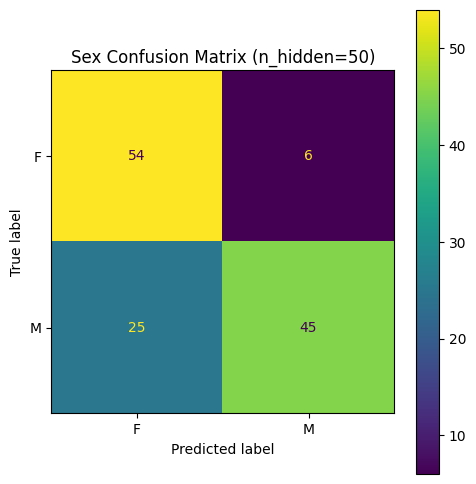


Results for hidden nodes=100

Age Confidence Scores (first 5 samples):
 [[0.255 0.745]
 [0.692 0.308]
 [0.788 0.212]
 [0.245 0.755]
 [0.462 0.538]]

Sex Confidence Scores (first 5 samples):
 [[0.812 0.188]
 [0.697 0.303]
 [0.066 0.934]
 [0.954 0.046]
 [0.038 0.962]]


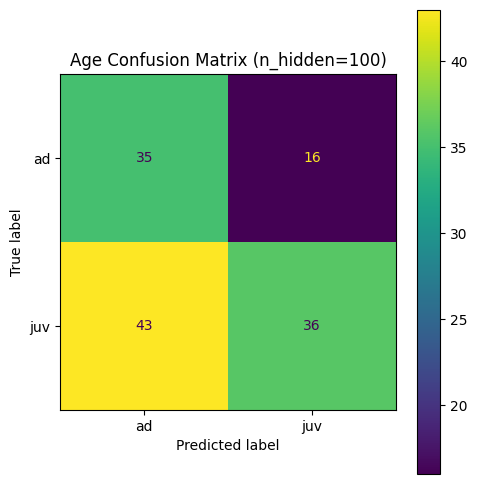

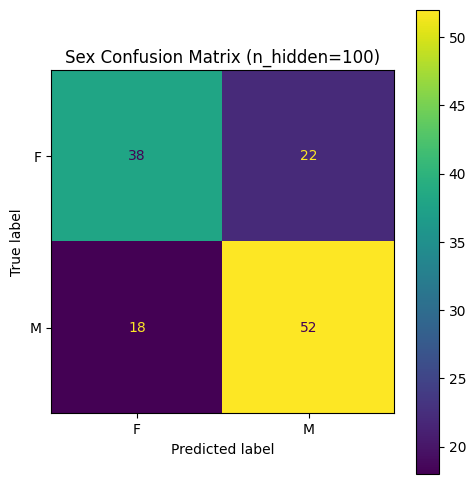

In [ ]:
# =========================================================
# Main
# =========================================================
import pandas as pd
import re
import os

def parse_subject(text):
    # Default structure
    result = {
        "year": None,
        "age": None,
        "id": None,
        "sex": None,
        "type": None
    }

    if pd.isna(text):
        return result

    parts = [p.strip() for p in text.split(";")]

    for p in parts:
        if re.fullmatch(r"\d{4}", p):
            result["year"] = int(p)

        elif p.lower() in {"juv", "ad"}:
            result["age"] = p.lower()

        elif re.fullmatch(r"[A-Z]{2}-\d{2}-\d{3}", p):
            result["id"] = p

        elif p in {"M", "F"}:
            result["sex"] = p

        else:
            # fallback (like "Wing")
            result["type"] = p

    return result

def main():
    # Ensure training set image labels.csv exists
    if not os.path.exists(CSV_PATH):
        print(f"'{CSV_PATH}' not found, generating it...")

        # Ensure wings_metadata.csv exists before attempting to read it
        if not os.path.exists("wings_metadata.csv"):
            raise FileNotFoundError(
                "'wings_metadata.csv' not found. "
                "Please ensure the cell that generates 'wings_metadata.csv' (cell klPETA55xmWb) "
                "has been executed successfully before running this cell."
            )

        wings_df = pd.read_csv("wings_metadata.csv")
        parsed = wings_df["XMP:Subject"].apply(parse_subject)
        parsed_df = pd.DataFrame(parsed.tolist())
        parsed_df = parsed_df.drop(columns=['year', 'id', 'type'], axis=1)
        parsed_df['filename']= wings_df['file_name']
        parsed_df.to_csv(CSV_PATH, index=False)
        print(f"'{CSV_PATH}' generated.")

    (
        X_train, y_age_train, y_sex_train,
        X_test, y_age_test, y_sex_test,
        label_maps
    ) = load_wings_mlp_multi(
        csv_path=CSV_PATH,
        image_dir=IMAGE_DIR,
        image_size=IMAGE_SIZE,
        test_size=TEST_SIZE,
        seed=SEED,
        grayscale=GRAYSCALE
    )

    print("Loaded data:")
    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("Age classes:", label_maps["age_to_idx"])
    print("Sex classes:", label_maps["sex_to_idx"])

    hidden_sizes = [20, 50, 100]

    results = {}

    # -------------------------------------------------
    # Experiments to run: (hidden layer sizes, learning rates and batch size)
    # -------------------------------------------------
    for n_hidden in hidden_sizes:
        print(f"\nTraining model with n_hidden={n_hidden}")

        weights_hidden, weights_age, weights_sex, history = mlp_train_multi(
            X_train, y_age_train, y_sex_train,
            X_test, y_age_test, y_sex_test,
            n_hidden=n_hidden,
            eta=0.01,
            momentum=0.9,
            epochs=42,
            batch_size=32, # Passed new batch_size parameter
            seed=42
        )

        results[n_hidden] = (weights_hidden, weights_age, weights_sex, history)

    plot_results_multi(results, title="Multi-output MLP on Wing Images")

    print("\nFinal accuracies:")
    for n_hidden, (_, _, _, history) in results.items():
        print(
            f"hidden nodes={n_hidden}: "
            f"age train={history['train_age_accs'][-1]:.4f}, age test={history['test_age_accs'][-1]:.4f} | "
            f"sex train={history['train_sex_accs'][-1]:.4f}, sex test={history['test_sex_accs'][-1]:.4f}"
        )

    # confusion matrices and confidence scores
    for n_hidden, (weights_hidden, weights_age, weights_sex, _) in results.items():
        print(f"\nResults for hidden nodes={n_hidden}")

        age_pred, sex_pred, age_confidence, sex_confidence = mlp_predict_multi(X_test, weights_hidden, weights_age, weights_sex)

        print("\nAge Confidence Scores (first 5 samples):\n", age_confidence[:5].round(3))
        print("\nSex Confidence Scores (first 5 samples):\n", sex_confidence[:5].round(3))

        plot_confusion_matrix_single(
            y_age_test,
            age_pred,
            label_maps["idx_to_age"],
            title=f"Age Confusion Matrix (n_hidden={n_hidden})",
            filename=f"cm_age_{n_hidden}.png"
        )

        plot_confusion_matrix_single(
            y_sex_test,
            sex_pred,
            label_maps["idx_to_sex"],
            title=f"Sex Confusion Matrix (n_hidden={n_hidden})",
            filename=f"cm_sex_{n_hidden}.png"
        )


if __name__ == "__main__":
    main()


# Appendix

- **Prompt:** rename all the files in the Wings folder in my drive to img_name_ year where the year is the folder name. Then extract all the meta data for each img using exiftool.
- **Response:** Sure I'd be happy to rename the files and extract metadata for you. (Edited code)





In [ ]:
import os

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

!pip install nbconvert >/dev/null
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc >/dev/null
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc >/dev/null

!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/CS 527 Final Project" >/dev/null

Mounted at /content/drive
Extracting templates from packages: 100%
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/CS 527 Final Project to pdf
[NbConvertApp] Support files will be in CS 527 Final Projec_files/
[NbConvertApp] Making directory ./CS 527 Final Projec_files
[NbConvertApp] Writing 126354 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 514917 bytes to /content/drive/MyDrive/Colab Notebooks/CS 527 Final Projec.pdf
